
# Ejercicio 3 — Gneración y distribución de energía eléctrica con Algoritmo Genético

Este notebook contiene el desarrollo del ejercicio #3.  
Se sigue el esquema de la guía: **población, evaluación, selección, cruce, mutación y nueva generación**.



## 1. Datos del problema

Cada cromosoma tiene 15 genes, uno por cada GW de demanda total.

- `0`: Planta Cali
- `1`: Planta Bogotá
- `2`: Planta Medellín
- `3`: Planta Barranquilla

Las posiciones del cromosoma están asociadas a las demandas:

- Cali: 4 genes
- Bogotá: 3 genes
- Medellín: 5 genes
- Barranquilla: 3 genes

Así, la demanda siempre se satisface y solo se debe controlar que ninguna planta supere su capacidad.


In [8]:

#librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos del problema
plantas = ["Planta Cali", "Planta Bogotá", "Planta Medellín", "Planta Barranquilla"]
ciudades = ["Cali", "Bogotá", "Medellín", "Barranquilla"]

# Capacidades máximas de generación
capacidades = np.array([3, 6, 5, 4])      # GW/día
demandas = np.array([4, 3, 5, 3])         # GW/día

costos_generacion = np.array([680, 720, 660, 750])

costos_transporte = np.array([
    [1, 4, 3, 6],
    [4, 1, 4, 5],
    [3, 4, 1, 4],
    [6, 5, 4, 1]
])

# Ciudad asociada a cada posición del cromosoma
ciudad_por_gen = np.repeat(np.arange(4), demandas)

print("Demanda total:", demandas.sum(), "GW/día")
print("Capacidad total:", capacidades.sum(), "GW/día")


Demanda total: 15 GW/día
Capacidad total: 18 GW/día


## 2. Funciones del algoritmo genético

In [9]:

PENALIZACION = 5000

def generar_individuo():
    # Se representan los 18 GW disponibles según la capacidad de cada planta
    energia_disponible = np.repeat(np.arange(4), capacidades)

    # Se toman 15 GW para cubrir la demanda total
    indices = np.random.choice(len(energia_disponible), demandas.sum(), replace=False)
    cromosoma = energia_disponible[indices].copy()
    np.random.shuffle(cromosoma)

    return cromosoma.tolist()


def generar_poblacion(K):
    return [generar_individuo() for _ in range(K)]


def evaluar(cromosoma):
    # Construye la matriz planta-ciudad
    despacho = np.zeros((4, 4), dtype=int)

    for planta, ciudad in zip(cromosoma, ciudad_por_gen):
        despacho[planta, ciudad] += 1

    generacion = despacho.sum(axis=1)

    # Exceso de capacidad de las plantas
    exceso = np.maximum(generacion - capacidades, 0).sum()

    # Costos
    costo_gen = np.sum(generacion * costos_generacion)
    costo_trans = np.sum(despacho * costos_transporte)
    costo_total = costo_gen + costo_trans

    # Penalización si una planta supera su capacidad
    costo_penalizado = costo_total + PENALIZACION * exceso

    return despacho, costo_total, costo_penalizado, exceso


def seleccion(poblacion, costos):
    # Selección por clasificación:
    # menor costo = mayor aptitud
    K = len(poblacion)
    orden = np.argsort(costos)

    aptitudes = np.empty(K)
    aptitudes[orden] = np.arange(K, 0, -1)
    probabilidades = aptitudes / aptitudes.sum()

    indices = np.random.choice(K, K, replace=True, p=probabilidades)
    return [poblacion[i].copy() for i in indices]


def cruce(padres, prob_cruce=0.90):
    # Cruce en dos puntos
    hijos = []
    orden = np.random.permutation(len(padres))

    for i in range(0, len(padres), 2):
        p1 = padres[orden[i]].copy()
        p2 = padres[orden[i + 1]].copy()

        if np.random.rand() < prob_cruce:
            a, b = np.sort(np.random.choice(np.arange(1, len(p1)), 2, replace=False))
            h1 = p1[:a] + p2[a:b] + p1[b:]
            h2 = p2[:a] + p1[a:b] + p2[b:]
        else:
            h1, h2 = p1, p2

        hijos.extend([h1, h2])

    return hijos


def mutacion(hijos, prob_mut):
    # Un gen cambia a otra planta
    for hijo in hijos:
        for i in range(len(hijo)):
            if np.random.rand() < prob_mut:
                opciones = [0, 1, 2, 3]
                opciones.remove(hijo[i])
                hijo[i] = int(np.random.choice(opciones))

    return hijos



## 3. Ejecución del algoritmo

Se usan 200 individuos y 300 generaciones. La probabilidad de mutación disminuye gradualmente para explorar más al inicio y conservar mejores soluciones al final.


In [10]:

def algoritmo_genetico(K=200, M=300, n_elite=4):
    poblacion = generar_poblacion(K)

    mejor_costo = np.inf
    mejor_despacho = None
    historial = []

    for gen in range(M):

        # Evaluación
        evaluaciones = [evaluar(c) for c in poblacion]
        costos_pen = np.array([e[2] for e in evaluaciones])

        # Guardar la mejor solución factible
        for despacho, costo, _, exceso in evaluaciones:
            if exceso == 0 and costo < mejor_costo:
                mejor_costo = costo
                mejor_despacho = despacho.copy()

        historial.append(mejor_costo)

        # Elitismo
        orden = np.argsort(costos_pen)
        elites = [poblacion[i].copy() for i in orden[:n_elite]]

        # Selección y cruce
        padres = seleccion(poblacion, costos_pen)
        hijos = cruce(padres)

        # Mutación variable: de 0.12 a 0.02
        prob_mut = 0.12 - 0.10 * gen / max(M - 1, 1)
        hijos = mutacion(hijos, prob_mut)

        # Nueva generación
        poblacion = elites + hijos[:K - n_elite]

    return mejor_costo, mejor_despacho, historial



## 4. Resultados

Como el algoritmo es aleatorio, se realizan 5 corridas y se conserva la mejor.


In [11]:

resultados = []

for i in range(5):
    costo, despacho, historial = algoritmo_genetico()
    resultados.append((costo, despacho, historial))
    print(f"Corrida {i+1}: costo = {costo:.0f}")

mejor_costo, mejor_despacho, historial = min(resultados, key=lambda x: x[0])

tabla = pd.DataFrame(
    mejor_despacho,
    index=plantas,
    columns=ciudades
)

tabla["Total generado"] = mejor_despacho.sum(axis=1)

print("\nMejor despacho encontrado:")
display(tabla)

print("Demanda abastecida:", mejor_despacho.sum(axis=0))
print("Capacidad utilizada:", mejor_despacho.sum(axis=1))
print("Mejor costo total:", mejor_costo)


Corrida 1: costo = 10436
Corrida 2: costo = 10436
Corrida 3: costo = 10436
Corrida 4: costo = 10436
Corrida 5: costo = 10438

Mejor despacho encontrado:


,Cali,Bogotá,Medellín,Barranquilla,Total generado
Planta Cali,3,0,0,0,3
Planta Bogotá,1,3,0,2,6
Planta Medellín,0,0,5,0,5
Planta Barranquilla,0,0,0,1,1


Demanda abastecida: [4 3 5 3]
Capacidad utilizada: [3 6 5 1]
Mejor costo total: 10436


In [12]:

# Descomposición del costo final
generacion_final = mejor_despacho.sum(axis=1)

costo_generacion_final = np.sum(generacion_final * costos_generacion)
costo_transporte_final = np.sum(mejor_despacho * costos_transporte)

print("Costo de generación:", costo_generacion_final)
print("Costo de transporte:", costo_transporte_final)
print("Costo total:", costo_generacion_final + costo_transporte_final)


Costo de generación: 10410
Costo de transporte: 26
Costo total: 10436


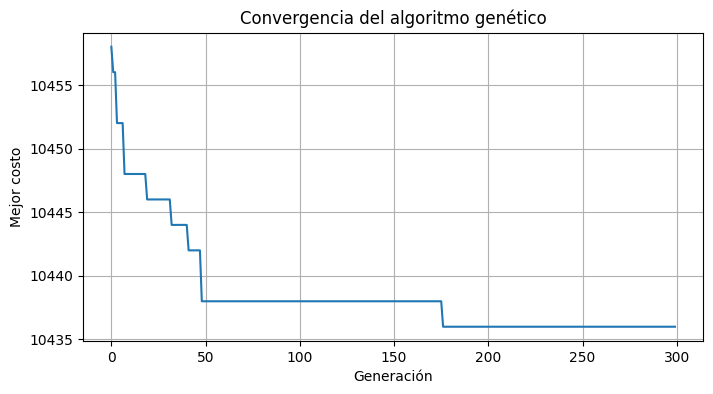

In [13]:

# Evolución del mejor costo encontrado
plt.figure(figsize=(8, 4))
plt.plot(historial)
plt.xlabel("Generación")
plt.ylabel("Mejor costo")
plt.title("Convergencia del algoritmo genético")
plt.grid(True)
plt.show()
